📡 Connecting to Financial Servers for 2018-TODAY Data...


/tmp/ipykernel_5607/4136245491.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([t.split('.')[0] for t in tickers], rotation=0, fontweight='bold')
/tmp/ipykernel_5607/4136245491.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


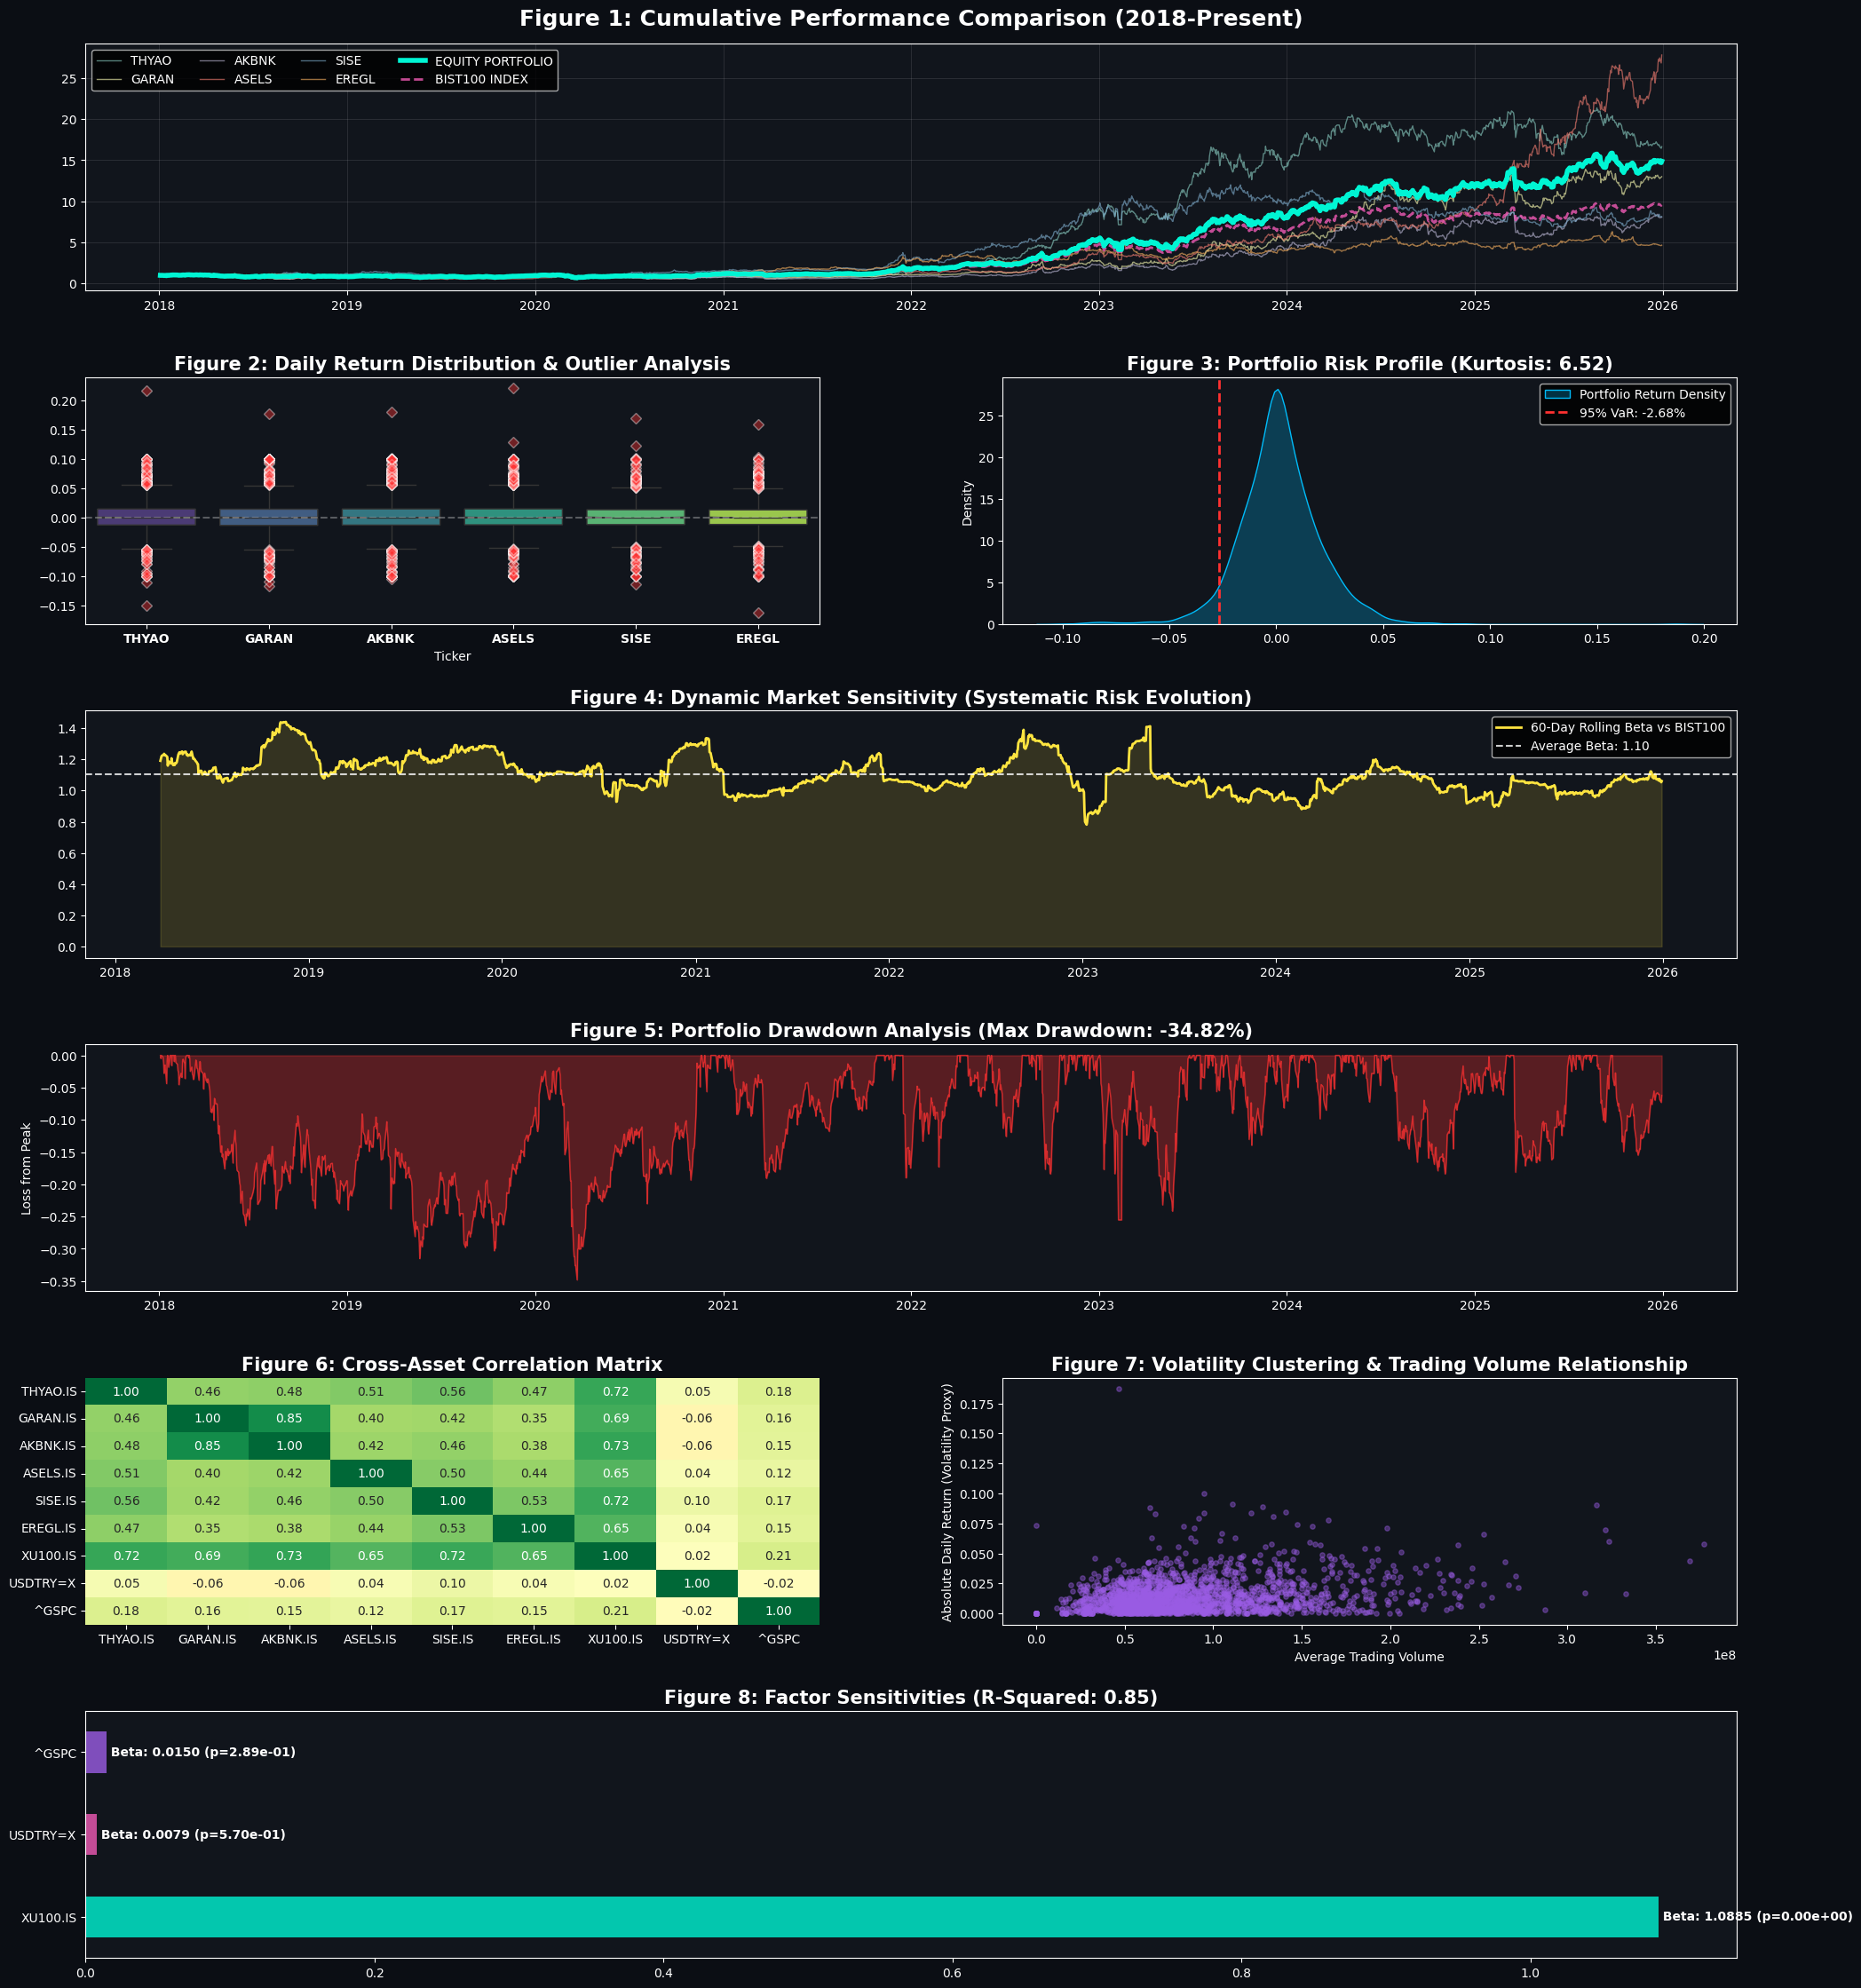


ACADEMIC SUMMARY STATISTICS
1. Systematic Risk (Mean Beta): 1.1044
2. Risk at Peril (95% VaR): -2.6815%
3. Recovery Metric (Max Drawdown): -34.8212%
4. Portfolio Kurtosis (Tail Risk): 6.5210
5. Regression p-values:
const       0.402290
XU100.IS    0.000000
USDTRY=X    0.570031
^GSPC       0.289444
dtype: float64


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from matplotlib.gridspec import GridSpec

tickers = ['THYAO.IS', 'GARAN.IS', 'AKBNK.IS', 'ASELS.IS', 'SISE.IS', 'EREGL.IS']
market = 'XU100.IS'
macro = 'USDTRY=X'
world = '^GSPC'

print("📡 Connecting to Financial Servers for 2018-TODAY Data...")

raw_data = yf.download(
    tickers + [market, macro, world],
    start='2018-01-01',
    end='2025-12-31',
    progress=False,
    auto_adjust=False
)

prices = raw_data['Close'].ffill()
volumes = raw_data['Volume'].ffill()

prices = prices.dropna(axis=1, how='all')
volumes = volumes.dropna(axis=1, how='all')

needed_cols = tickers + [market, macro, world]
available_cols = [c for c in needed_cols if c in prices.columns]

data = prices[available_cols].dropna()
returns = data.pct_change().dropna()

stock_ret = returns[tickers]
mkt_ret = returns[market]
fx_ret = returns[macro]
global_ret = returns[world]
port_ret = stock_ret.mean(axis=1)

var_95 = np.percentile(port_ret, 5)

cum_port = (1 + port_ret).cumprod()
rolling_max = cum_port.cummax()
drawdown = (cum_port - rolling_max) / rolling_max
max_dd = drawdown.min()

window = 60
rolling_beta = port_ret.rolling(window).cov(mkt_ret) / mkt_ret.rolling(window).var()
rolling_beta = rolling_beta.dropna()

plt.style.use('dark_background')
fig = plt.figure(figsize=(24, 28), facecolor='#0B0E14')
gs = GridSpec(6, 2, figure=fig, hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#11151C')

for t in tickers:
    ax1.plot((1 + stock_ret[t]).cumprod(), label=t.split('.')[0], alpha=0.6, lw=1)

ax1.plot(cum_port, color='#00F5D4', lw=4, label='EQUITY PORTFOLIO', zorder=5)
ax1.plot((1 + mkt_ret).cumprod(), color='#F15BB5', lw=2, ls='--', label='BIST100 INDEX', alpha=0.8)
ax1.set_title("Figure 1: Cumulative Performance Comparison (2018-Present)", fontsize=18, fontweight='bold', pad=15)
ax1.legend(loc='upper left', ncol=4, frameon=True)
ax1.grid(alpha=0.1)

ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#11151C')

sns.boxplot(
    data=stock_ret,
    palette='viridis',
    notch=True,
    ax=ax2,
    flierprops={
        'marker': 'D',
        'markerfacecolor': '#FF3131',
        'markeredgecolor': 'white',
        'alpha': 0.4
    }
)

ax2.set_xticklabels([t.split('.')[0] for t in tickers], rotation=0, fontweight='bold')
ax2.set_title("Figure 2: Daily Return Distribution & Outlier Analysis", fontsize=15, fontweight='bold')
ax2.axhline(0, color='white', ls='--', alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#11151C')

sns.kdeplot(port_ret, fill=True, color='#00BBF9', ax=ax3, label='Portfolio Return Density')
ax3.axvline(var_95, color='#FF3131', ls='--', lw=2, label=f'95% VaR: {var_95:.2%}')
ax3.set_title(f"Figure 3: Portfolio Risk Profile (Kurtosis: {port_ret.kurt():.2f})", fontsize=15, fontweight='bold')
ax3.legend()

ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor('#11151C')

ax4.fill_between(rolling_beta.index, rolling_beta.values, color='#FEE440', alpha=0.15)
ax4.plot(rolling_beta.index, rolling_beta.values, color='#FEE440', lw=2, label='60-Day Rolling Beta vs BIST100')
ax4.axhline(rolling_beta.mean(), color='white', ls='--', alpha=0.8, label=f'Average Beta: {rolling_beta.mean():.2f}')
ax4.set_title("Figure 4: Dynamic Market Sensitivity (Systematic Risk Evolution)", fontsize=15, fontweight='bold')
ax4.legend()

ax5 = fig.add_subplot(gs[3, :])
ax5.set_facecolor('#11151C')

ax5.fill_between(drawdown.index, drawdown.values, 0, color='#FF3131', alpha=0.3)
ax5.plot(drawdown.index, drawdown.values, color='#FF3131', lw=1, alpha=0.7)
ax5.set_title(f"Figure 5: Portfolio Drawdown Analysis (Max Drawdown: {max_dd:.2%})", fontsize=15, fontweight='bold')
ax5.set_ylabel("Loss from Peak")

ax6 = fig.add_subplot(gs[4, 0])

full_corr = pd.concat([stock_ret, mkt_ret, fx_ret, global_ret], axis=1).corr()
sns.heatmap(full_corr, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax6, cbar=False, center=0)
ax6.set_title("Figure 6: Cross-Asset Correlation Matrix", fontsize=15, fontweight='bold')

ax7 = fig.add_subplot(gs[4, 1])
ax7.set_facecolor('#11151C')

avg_volume = volumes[tickers].mean(axis=1)

scatter_data = pd.DataFrame({
    'Average Volume': avg_volume,
    'Absolute Return': port_ret.abs()
}).dropna()

ax7.scatter(
    scatter_data['Average Volume'],
    scatter_data['Absolute Return'],
    alpha=0.4,
    color='#9b5de5',
    s=15
)

ax7.set_title("Figure 7: Volatility Clustering & Trading Volume Relationship", fontsize=15, fontweight='bold')
ax7.set_xlabel("Average Trading Volume")
ax7.set_ylabel("Absolute Daily Return (Volatility Proxy)")

ax8 = fig.add_subplot(gs[5, :])
ax8.set_facecolor('#11151C')

X = pd.concat([mkt_ret, fx_ret, global_ret], axis=1).dropna()
X = sm.add_constant(X)

y = port_ret.loc[X.index]

reg_model = sm.OLS(y, X).fit()

reg_model.params[1:].plot(
    kind='barh',
    ax=ax8,
    color=['#00F5D4', '#F15BB5', '#9b5de5'],
    alpha=0.8
)

ax8.set_title(f"Figure 8: Factor Sensitivities (R-Squared: {reg_model.rsquared:.2f})", fontsize=15, fontweight='bold')

for i, v in enumerate(reg_model.params[1:]):
    ax8.text(
        v,
        i,
        f' Beta: {v:.4f} (p={reg_model.pvalues.iloc[i+1]:.2e})',
        va='center',
        fontweight='bold',
        color='white'
    )

plt.tight_layout()
plt.show()

print(f"\n{'='*80}\nACADEMIC SUMMARY STATISTICS\n{'='*80}")
print(f"1. Systematic Risk (Mean Beta): {rolling_beta.mean():.4f}")
print(f"2. Risk at Peril (95% VaR): {var_95:.4%}")
print(f"3. Recovery Metric (Max Drawdown): {max_dd:.4%}")
print(f"4. Portfolio Kurtosis (Tail Risk): {port_ret.kurt():.4f}")
print(f"5. Regression p-values:\n{reg_model.pvalues}")
print(f"{'='*80}")